In [134]:
import pandas as pd
df = pd.read_csv("/Users/sujithrathod/krish naik /linear regression/economic_index.csv")
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [135]:
df.drop(columns=['Unnamed: 0',"year","month"],axis = 1,inplace=True)

In [136]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [137]:
import matplotlib.pyplot as plt
import numpy as np


In [138]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

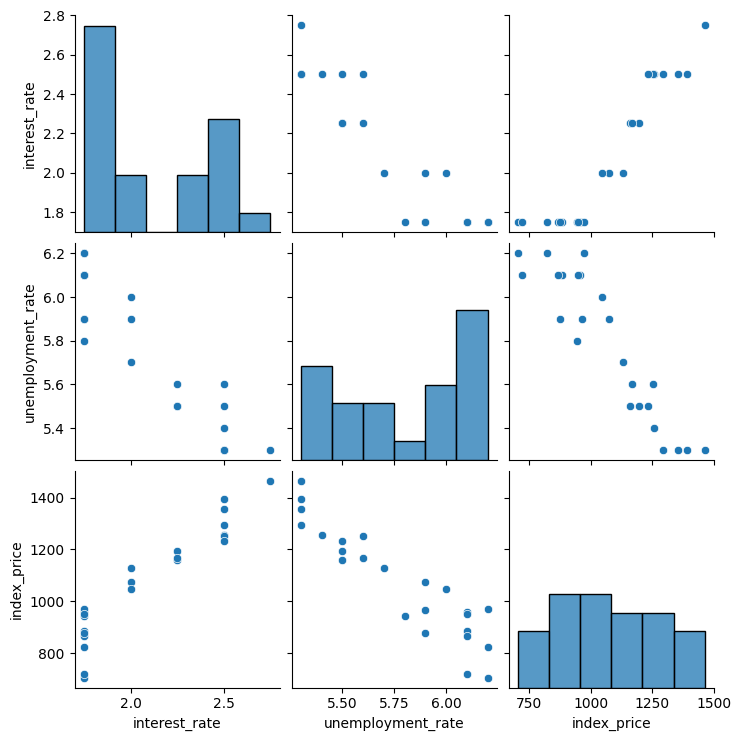

In [139]:
# visualization 
import seaborn as sns
sns.pairplot(df)

In [140]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemplyment rate')

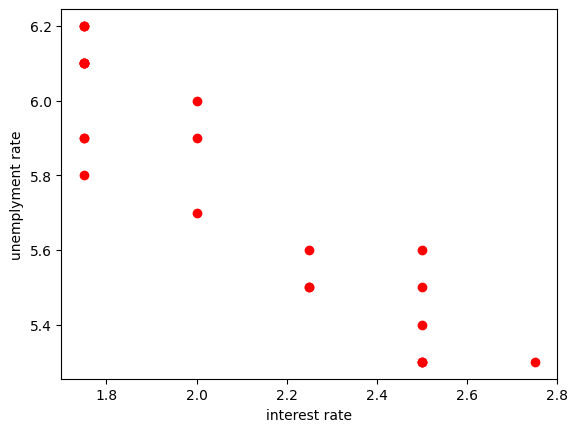

In [141]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='r')
plt.xlabel("interest rate")
plt.ylabel("unemplyment rate")

In [142]:
# indepedent and dependent features
x = df[['interest_rate','unemployment_rate']]    #use df.iloc[:,:-1]
y = df['index_price']                            #use df.iloc[:,-1]

In [143]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25, random_state=42)


<Axes: xlabel='interest_rate', ylabel='index_price'>

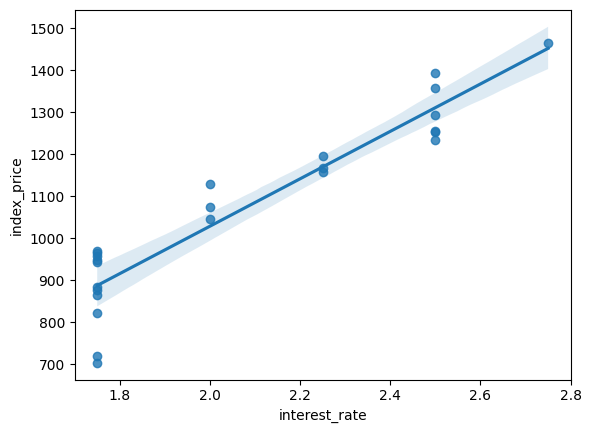

In [144]:
import seaborn as sns
sns.regplot(x = df['interest_rate'],y = df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

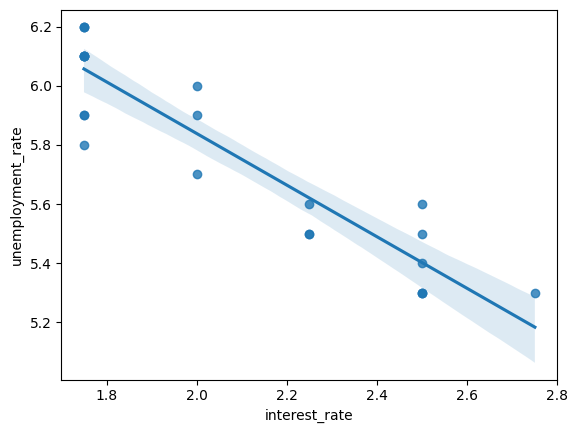

In [145]:
sns.regplot(x = df['interest_rate'], y = df['unemployment_rate'])

In [146]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)


In [147]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression()
model.fit(x_train,y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [148]:
# cross validation
from sklearn.model_selection import cross_val_score
validation_Score = cross_val_score(model,x_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [149]:
validation_Score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [150]:
np.mean(validation_Score)

np.float64(-5914.8281801623925)

In [151]:
# prediction 
y_pred = model.predict(x_test)

In [152]:
from sklearn.metrics import r2_score
r2_score(y_pred,y_test)

0.8026217218199293

In [153]:
# performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_pred,y_test)
mae = mean_absolute_error(y_pred,y_test)
rmse = np.sqrt(mse)
print("mse" , mse)
print("mae", mae)
print("rmse" , rmse)

mse 8108.567426306607
mae 73.80444932337097
rmse 90.04758423359623


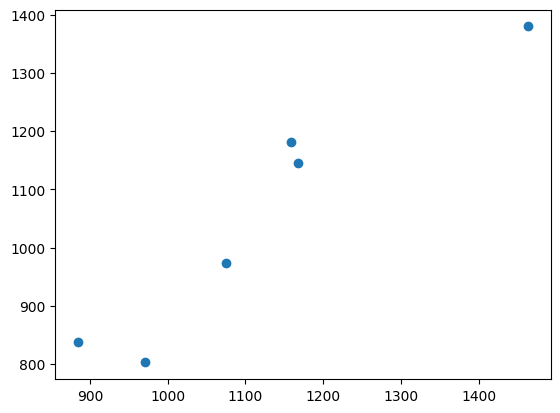

In [154]:
# assumptions
plt.scatter(y_test,y_pred)

In [155]:
residuals = y_test - y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


In [156]:
model.coef_

array([  88.27275507, -116.25716066])

In [157]:
model.intercept_

np.float64(1053.4444444444443)

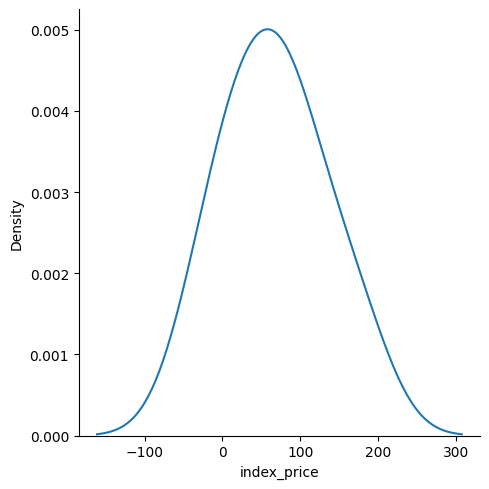

In [158]:
# plot this residuals
sns.displot(residuals,kind='kde')

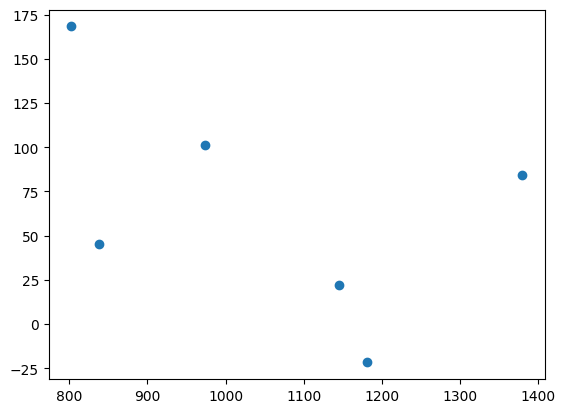

In [159]:
# scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

In [160]:
import statsmodels.api as sm 
model = sm.OLS(y_train,x_train).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Mon, 10 Nov 2025   Prob (F-statistic):                       0.754
Time:                        10:41:03   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""